In [1]:
# 라이브러리 호출
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

## 원본 데이터 호출 및 데이터프레임 제작

In [2]:
# 데이터 프레임을 출력할 때, 행과 컬럼이 모두 생략되지 않도록 하는 코드
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 원본 파일을 열어보니 컬럼명이 다중행이라서 두 행을 모두 불러옴
df_original = pd.read_csv("../data/DieCasting_Quality_Raw_Data.csv", header=[0,1])

df_original.head(5)

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

In [3]:
df_original.shape

(7535, 57)

In [4]:
# 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_original.columns if col[0] == 'Process']
sensor_cols = [col for col in df_original.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_original.columns if col[0] == 'Defects']

# 데이터 프레임 생성
df_process = df_original[process_cols].copy()
df_sensor = df_original[sensor_cols].copy()
df_defects = df_original[defects_cols].copy()

# 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

# csv 파일로 저장
df_process.to_csv('process.csv', index=False)
df_sensor.to_csv('sensor.csv', index=False)
df_defects.to_csv('defects.csv', index=False)

print("✅ 파일 분리 완료!")
print(f"Process: 컬럼 {len(process_cols)}개")
print(f"Sensor: 컬럼 {len(sensor_cols)}개")
print(f"Defects: 컬럼 {len(defects_cols)}개")

✅ 파일 분리 완료!
Process: 컬럼 17개
Sensor: 컬럼 14개
Defects: 컬럼 26개


---
## 결측치 개수 및 비율 확인

In [5]:
def show_df_info(df, df_name):
    
    print(f"{'='*60}")
    print(f"⬇️{df_name} 데이터프레임 정보⬇️")
    print(f"{'='*60}")
    
    # .values: Numpy 배열로 반환
    # 각각의 값이 인덱스가 안맞아서 DataFrame을 만들 때 충돌되지 않도록 하기 위해서 사용
    info_df = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null_Cnt': df.count().values,
        'Null_Cnt': df.isnull().sum().values,
        'Null_pct(%)': (df.isnull().sum() / len(df) * 100).round(2).values
    })
    
    display(info_df)
    return info_df

In [6]:
process_info = show_df_info(df_process, 'Process')
sensor_info = show_df_info(df_sensor, 'Sensor')
defects_info = show_df_info(df_defects, 'Defects')

⬇️Process 데이터프레임 정보⬇️


,Column Name,Data Type,Non-Null_Cnt,Null_Cnt,Null_pct(%)
0,id,int64,7535,0,0.0
1,Product_Type,int64,7535,0,0.0
2,Shot,int64,7535,0,0.0
3,Velocity_1,float64,7535,0,0.0
4,Velocity_2,float64,7535,0,0.0
5,Velocity_3,float64,7535,0,0.0
6,High_Velocity,float64,7535,0,0.0
7,Cylinder_Pressure,int64,7535,0,0.0
8,Rapid_Rise_Time,float64,7535,0,0.0
9,Biscuit_Thickness,int64,7535,0,0.0


⬇️Sensor 데이터프레임 정보⬇️


,Column Name,Data Type,Non-Null_Cnt,Null_Cnt,Null_pct(%)
0,Melting_Furnace_Temp,float64,7535,0,0.00
1,Air_Pressure,float64,7535,0,0.00
2,Air_Pressure_Min,int64,7535,0,0.00
3,Air_Pressure_Max,int64,7535,0,0.00
4,Coolant_Temp,float64,7535,0,0.00
5,Coolant_Temp_Min,int64,7535,0,0.00
6,Coolant_Temp_Max,int64,7535,0,0.00
7,Coolant_Pressure,float64,7535,0,0.00
8,Factory_Temp,float64,7445,90,1.19
9,Factory_Temp_Min,float64,7445,90,1.19


⬇️Defects 데이터프레임 정보⬇️


,Column Name,Data Type,Non-Null_Cnt,Null_Cnt,Null_pct(%)
0,Short_Shot_1,int64,7535,0,0.0
1,Bubble_1,int64,7535,0,0.0
2,Exfoliation_1,int64,7535,0,0.0
3,Blow_Hole_1,int64,7535,0,0.0
4,Stain_1,int64,7535,0,0.0
5,Dent_1,int64,7535,0,0.0
6,Deformation_1,int64,7535,0,0.0
7,Contamination_1,int64,7535,0,0.0
8,Impurity_1,int64,7535,0,0.0
9,Crack_1,int64,7535,0,0.0


---
## Cavity별 불량 발생 비율 시각화

In [7]:
# 불량율 Cavity 1, 2별로 분리
def split_by_cavity(df_defects):
    """Defects 데이터를 Cavity 1, Cavity 2로 분리"""
    
    # Cavity 1 (_1로 끝나는 컬럼)
    cavity_1_cols = [col for col in df_defects.columns if col.endswith('_1')]
    df_cavity_1 = df_defects[cavity_1_cols].copy()
    df_cavity_1.columns = df_cavity_1.columns.str.replace('_1', '')
    
    # Cavity 2 (_2로 끝나는 컬럼)
    cavity_2_cols = [col for col in df_defects.columns if col.endswith('_2')]
    df_cavity_2 = df_defects[cavity_2_cols].copy()
    df_cavity_2.columns = df_cavity_2.columns.str.replace('_2', '')
    
    return df_cavity_1, df_cavity_2

In [8]:
# 함수 실행
df_cavity_1, df_cavity_2 = split_by_cavity(df_defects)
print(f'Cavity 1의 불량 유형 수: {len(df_cavity_1.columns)}개')
print(f'Cavity 2의 불량 유형 수: {len(df_cavity_2.columns)}개')

Cavity 1의 불량 유형 수: 13개
Cavity 2의 불량 유형 수: 13개


In [9]:
# "Defects"에서 0,1의 개수 및 비율
# 0: 정상
# 1: 불량 

def analyze_defects_distribution(df, cavity_name):
    """불량 유형별 정상/불량 비율 분석"""
    print(f"{'='*60}")
    print(f"{cavity_name} - 불량 발생 비율")
    print(f"{'='*60}")
    
    defect_summary = [] # 빈 리스트 정의 
    total = len(df)
    
    for col in df.columns:
        value_counts = df[col].value_counts() # 0,1의 개수 계산
        
        count_0 = value_counts.get(0, 0)
        count_1 = value_counts.get(1, 0)
        
        pct_0 = round((count_0 / total * 100), 2)
        pct_1 = round((count_1 / total * 100), 2)
        
        # 딕셔너리를 만들어서 리스트에 추가
        defect_summary.append({
            'Defect Type': col,
            'Cnt_0 (정상)': count_0,
            'Pct_0 (%)': pct_0,
            'Cnt_1 (불량)': count_1,
            'Pct_1 (%)': pct_1,
            'Total': total
        })
    
    summary_df = pd.DataFrame(defect_summary) #pd.DataFrame은 리스트/딕셔너리를 데이터프레임으로 바꿔줌
    display(summary_df)
    
    return summary_df

In [10]:
# 함수 실행
cavity_1_distribution = analyze_defects_distribution(df_cavity_1, 'Cavity 1')
cavity_2_distribution = analyze_defects_distribution(df_cavity_2, 'Cavity 2')

Cavity 1 - 불량 발생 비율


,Defect Type,Cnt_0 (정상),Pct_0 (%),Cnt_1 (불량),Pct_1 (%),Total
0,Short_Shot,7038,93.40,482,6.40,7535
1,Bubble,7463,99.04,72,0.96,7535
2,Exfoliation,7362,97.70,171,2.27,7535
3,Blow_Hole,7314,97.07,199,2.64,7535
4,Stain,7346,97.49,169,2.24,7535
5,Dent,7528,99.91,7,0.09,7535
6,Deformation,7427,98.57,107,1.42,7535
7,Contamination,7531,99.95,4,0.05,7535
8,Impurity,7533,99.97,2,0.03,7535
9,Crack,7534,99.99,1,0.01,7535


Cavity 2 - 불량 발생 비율


,Defect Type,Cnt_0 (정상),Pct_0 (%),Cnt_1 (불량),Pct_1 (%),Total
0,Short_Shot,7355,97.61,178,2.36,7535
1,Bubble,7528,99.91,5,0.07,7535
2,Exfoliation,7404,98.26,128,1.70,7535
3,Blow_Hole,7380,97.94,149,1.98,7535
4,Stain,7535,100.00,0,0.00,7535
5,Dent,7531,99.95,4,0.05,7535
6,Deformation,7471,99.15,63,0.84,7535
7,Contamination,7527,99.89,8,0.11,7535
8,Impurity,7530,99.93,5,0.07,7535
9,Crack,7533,99.97,2,0.03,7535


In [11]:
# Cavity별 불량 발생 비율 비교

def plot_defect_rate_comparison(cavity_1_df, cavity_2_df):
    
    plt.figure(figsize=(14, 6))
    
    x = range(len(cavity_1_df))
    width = 0.35
    
    # Cavity 1 불량률
    bars1 = plt.bar(
        [i - width / 2 for i in x], # x축 좌표 조정
        cavity_1_df["Pct_1 (%)"], # y값
        width,
        label="Cavity 1",
        color="#e74c3c",
        alpha=0.8
    )
    
    # Cavity 2 불량률
    bars2 = plt.bar(
        [i + width / 2 for i in x],
        cavity_2_df["Pct_1 (%)"],
        width,
        label="Cavity 2",
        color="#3498db",
        alpha=0.8
    )
    
    # 막대 위에 값 표시 (자동)
    plt.bar_label(bars1, fmt='%.2f', padding=1.3, fontsize=9)
    plt.bar_label(bars2, fmt='%.2f', padding=1.3, fontsize=9)
    
    plt.xlabel("불량 유형", fontsize=12)
    plt.ylabel("불량률 (%)", fontsize=12)
    plt.title("Cavity 1 vs Cavity 2 - 불량 유형별 불량 발생율 비교", fontsize=14, fontweight="bold")
    plt.xticks(x, cavity_1_df["Defect Type"], rotation=45, ha="right")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

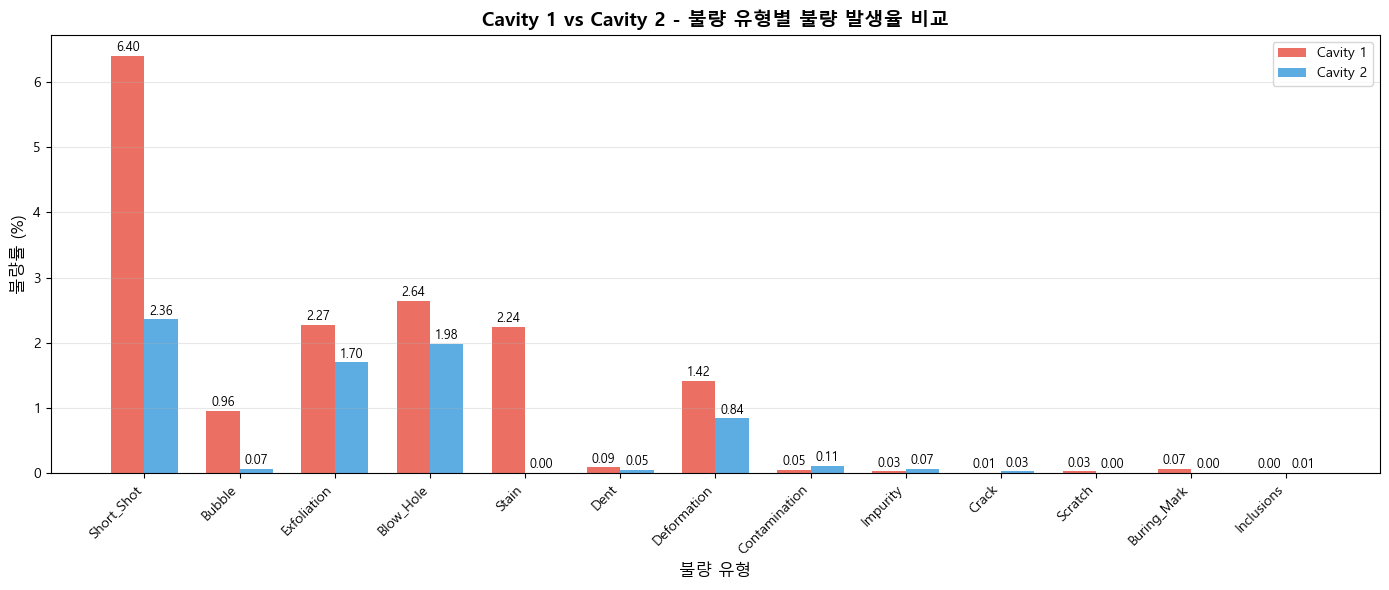

In [12]:
# 함수 실행
plot_defect_rate_comparison(cavity_1_distribution, cavity_2_distribution)

---
## Product, Sensor관련 데이터의 분포 시각화

In [13]:
# Product, Sensor관련 데이터의 분포 시각화(히스토그램)

def plot_histograms(df, df_name, exclude_cols=['id', 'Shot', 'Product_Type'], bins=30, figsize=(20, 15)):
    
    # id, shot 컬럼 제외
    plot_cols = [col for col in df.columns if col not in exclude_cols]
    
    n_cols = len(plot_cols)
    n_rows = int(np.ceil(n_cols / 5))
    
    fig, axes = plt.subplots(n_rows, 5, figsize=figsize)
    axes = axes.flatten() # 행+열로 구성된 인덱스를 순서 인덱스로 변경
    
    for idx, col in enumerate(plot_cols):
        ax = axes[idx]
        
        # 왼쪽 y축: 히스토그램 (빈도수)
        sns.histplot(df[col], bins=bins, ax=ax, kde=False,
                    stat='count',  # 빈도수
                    color='steelblue', 
                    edgecolor='black', 
                    alpha=0.7)
        
        ax.set_ylabel('Frequency', fontsize=8)
        
        # 오른쪽 y축: KDE (밀도)
        ax2 = ax.twinx()  # 두 번째 y축 생성
        sns.kdeplot(df[col], ax=ax2, color='red', linewidth=2)
        
        ax2.set_ylabel('Density', fontsize=8)
        
        # 제목 및 x축
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # 남은 subplot 제거
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle(f'{df_name}와 관련된 데이터들의 Histograms과 KDE 곡선', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

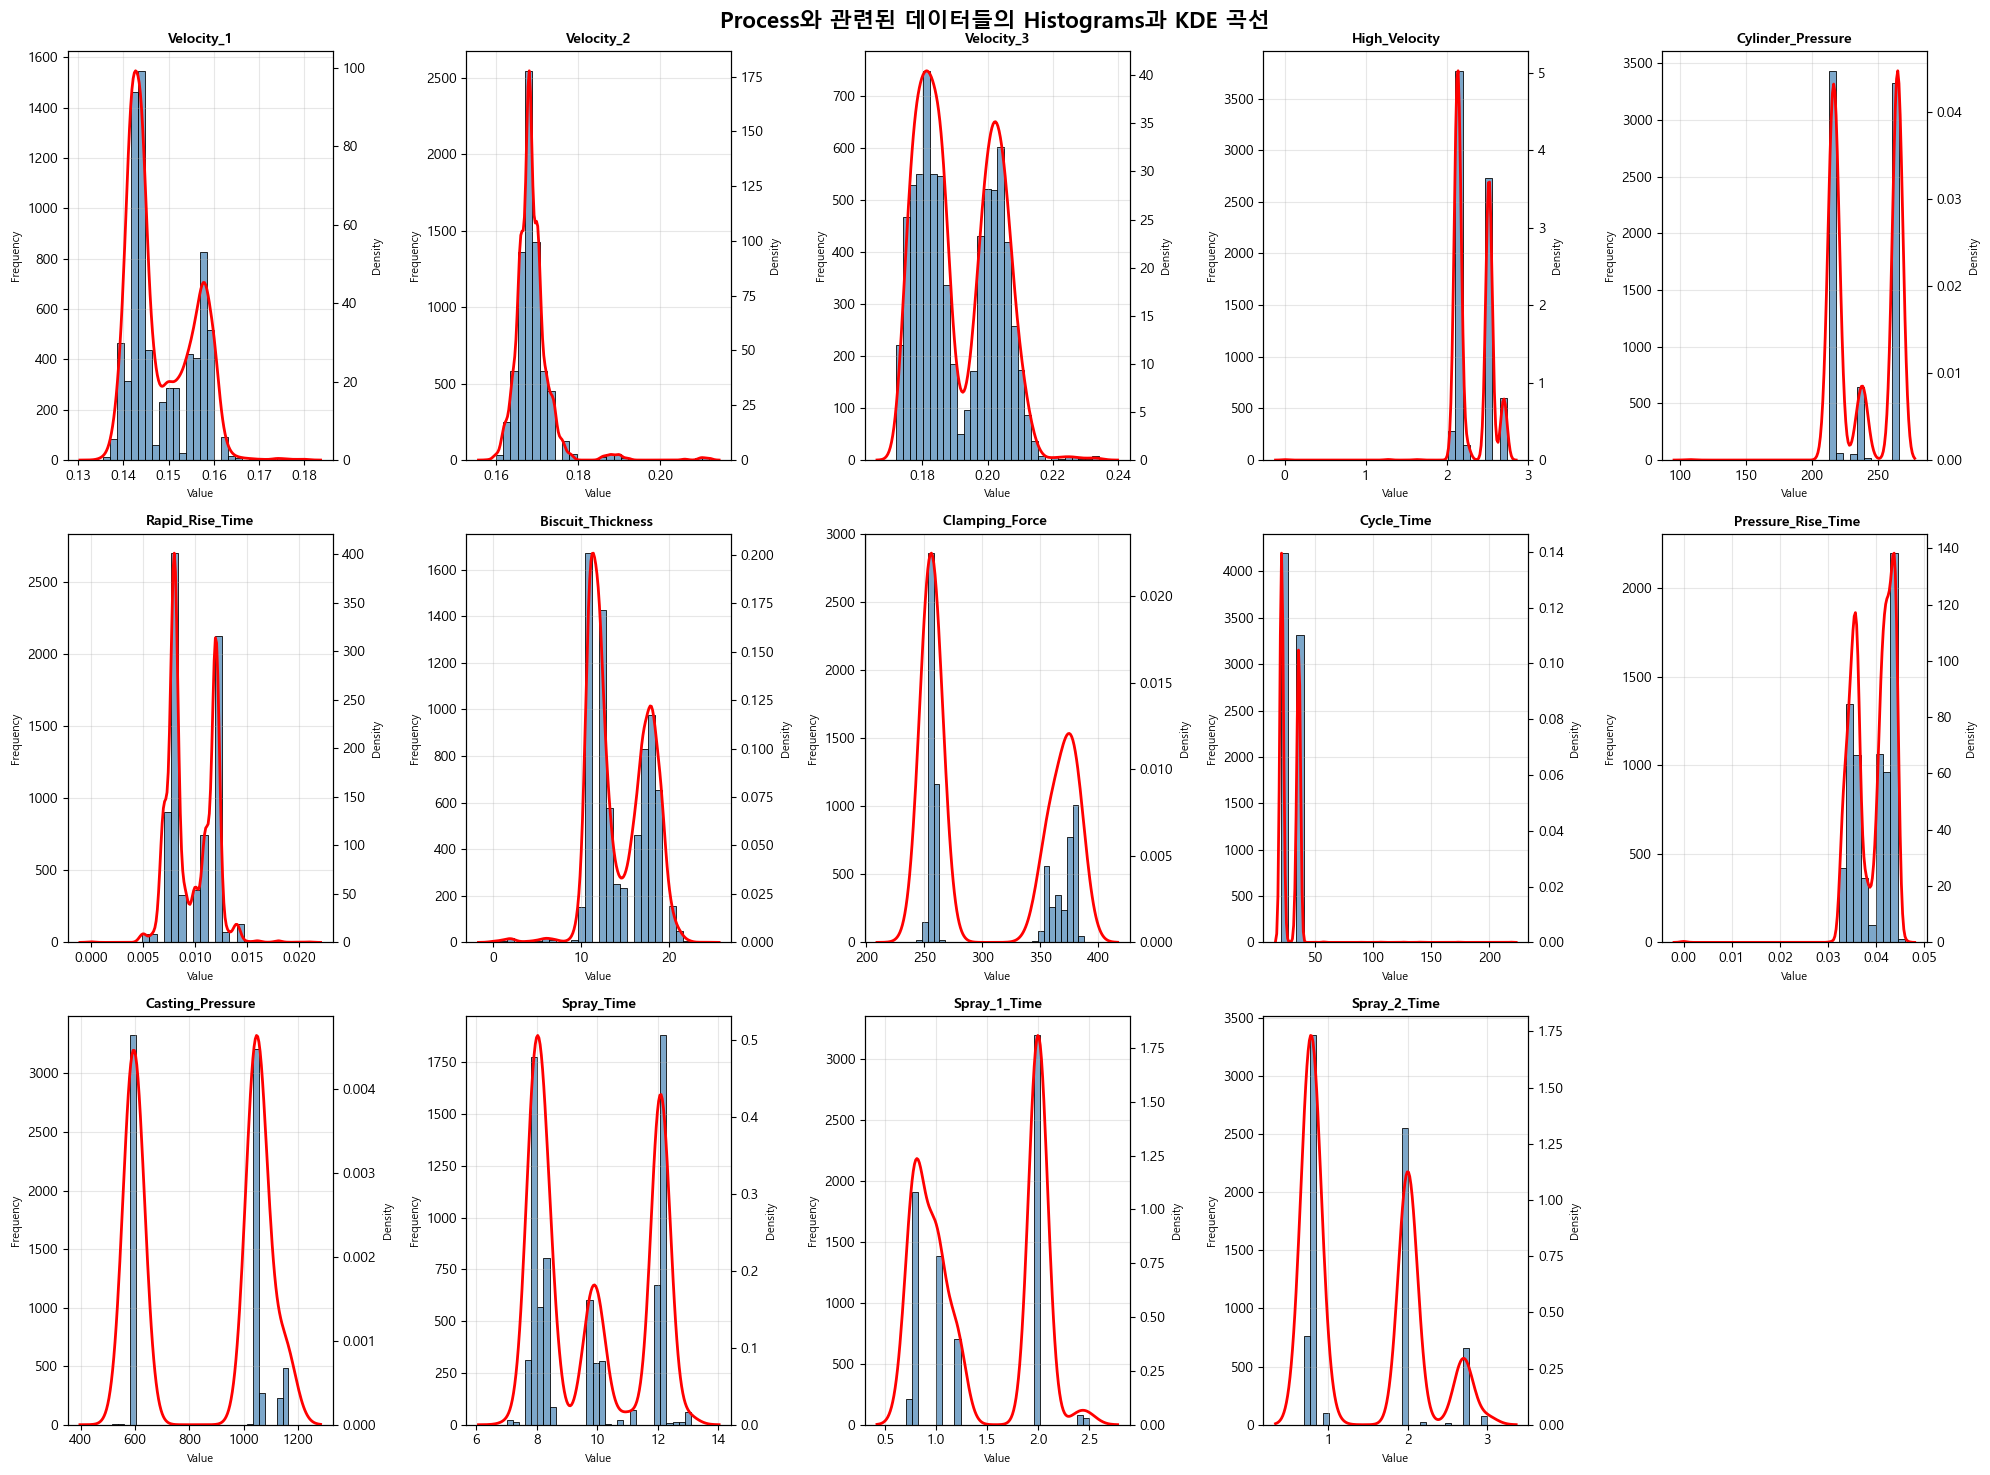

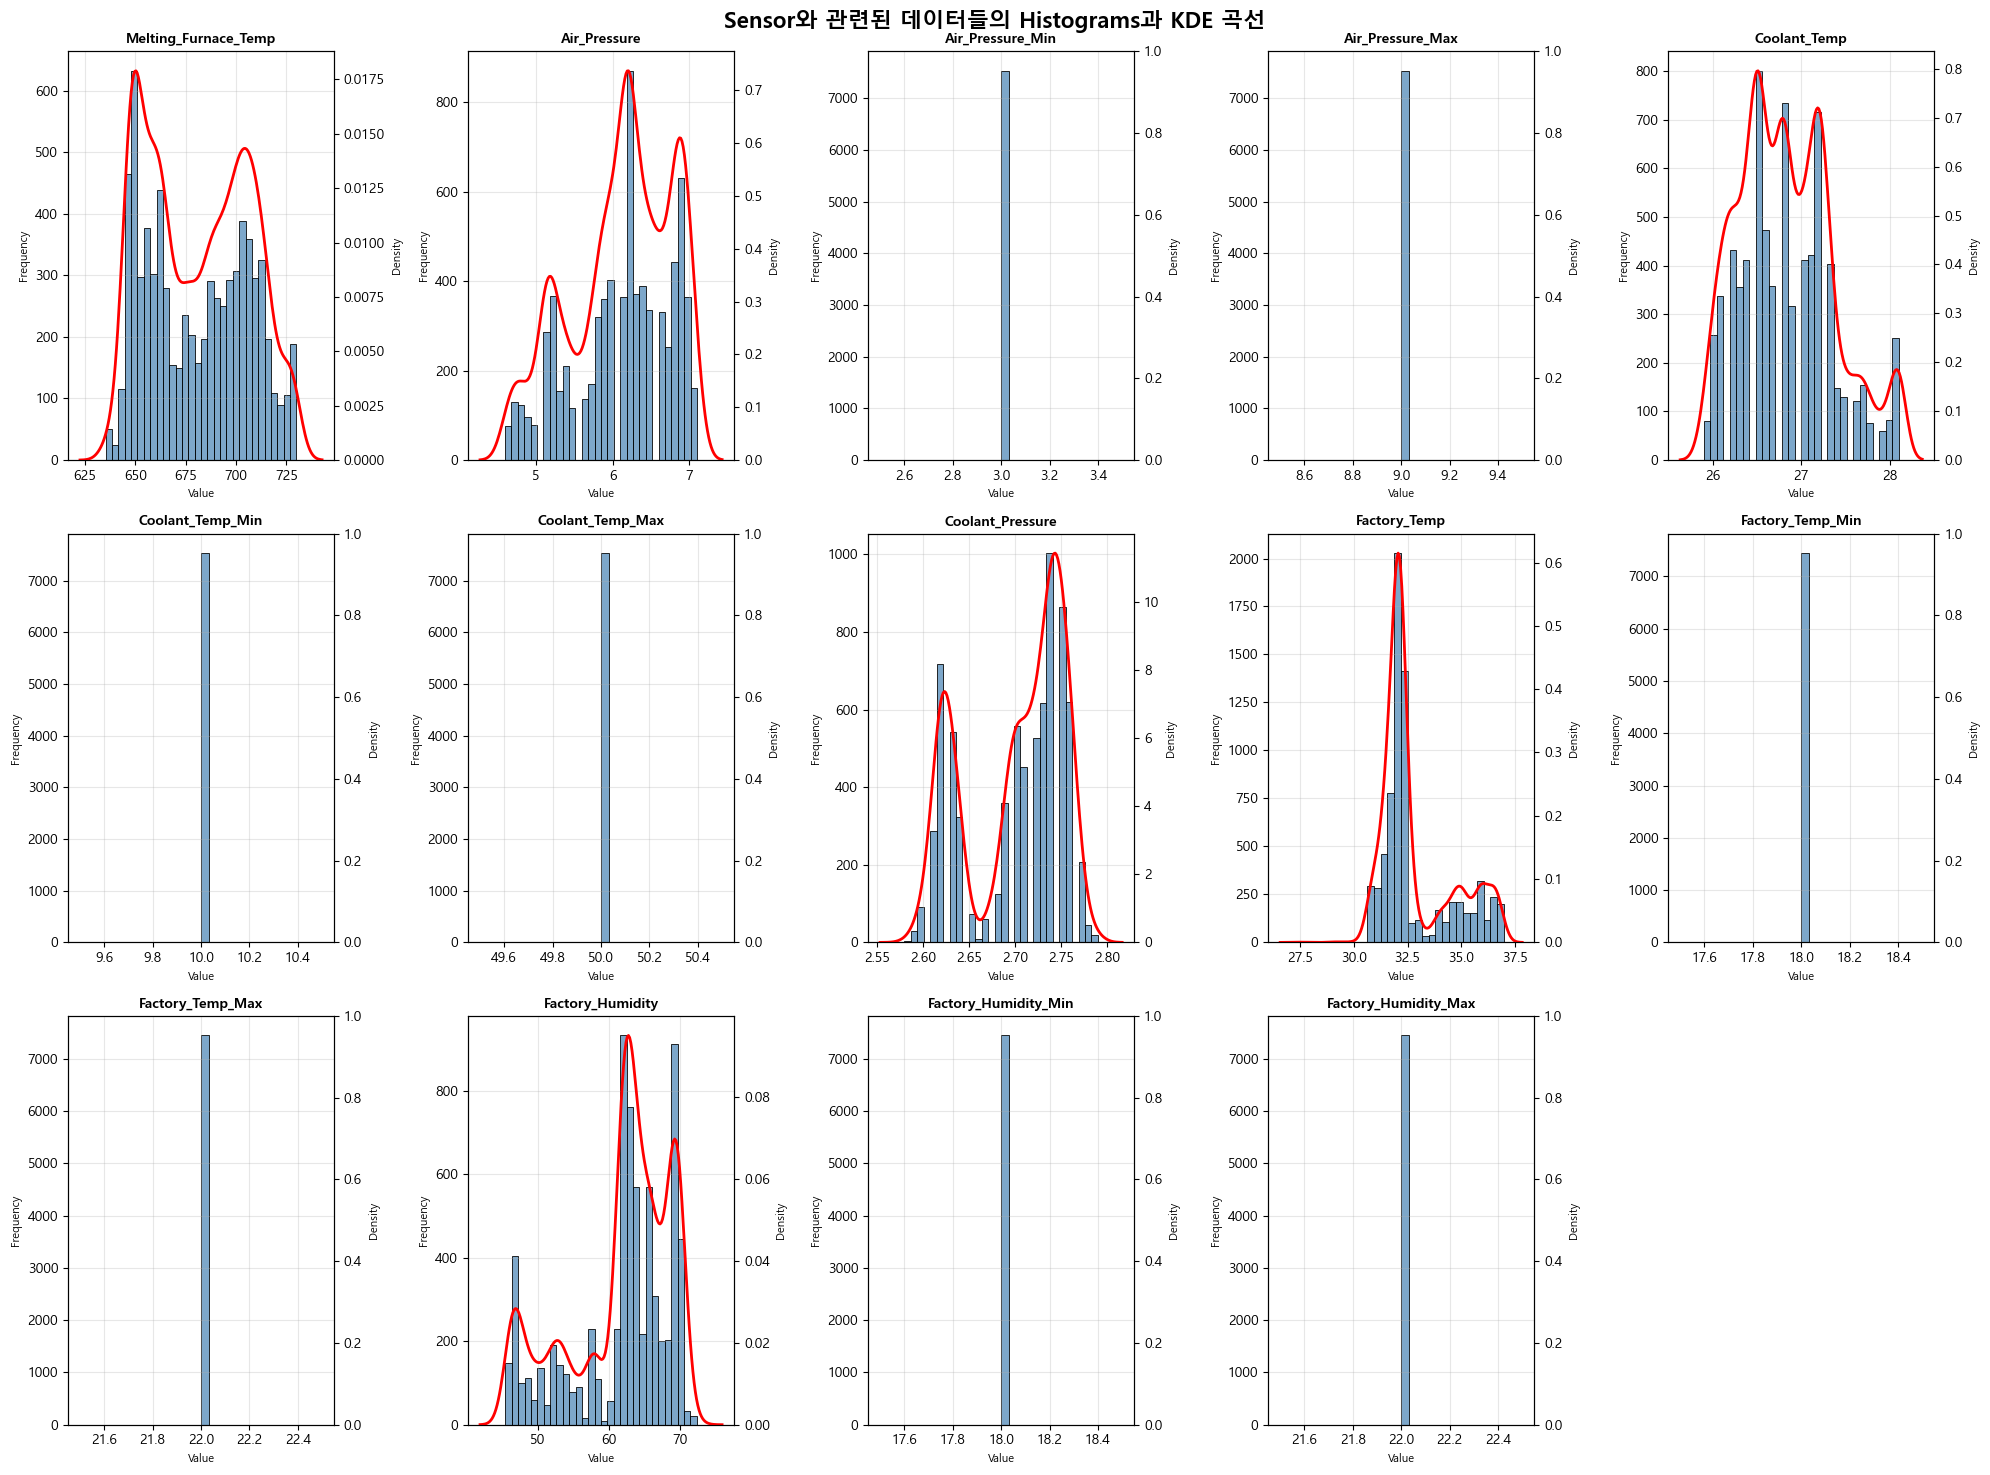

In [22]:
# 함수 실행
plot_histograms(df_process, 'Process')
plot_histograms(df_sensor, 'Sensor')

---
## 결측치가 존재한 컬럼들의 분포 확인

In [15]:
# 결측치가 존재한 컬럼만 필터링해서 히스토그램으로 확인

def plot_null_columns(df, df_name, bins=30, figsize=(20, 15)):
    
    # 정보 가져오기
    info_df = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null_Cnt': df.count().values,
        'Null_Cnt': df.isnull().sum().values,
        'Null_pct(%)': (df.isnull().sum() / len(df) * 100).round(2).values
    })
    
    # 결측치 있는 컬럼 필터링
    null_info = info_df[info_df['Null_Cnt'] > 0]
    
    if len(null_info) == 0:
        print(f"\n{df_name}관련 데이터 중 결측치가 있는 컬럼이 없습니다.")
        return # 함수를 종료하라는 의미
    
    # 컬럼명 추출
    null_cols = null_info['Column Name'].tolist() # tolist(): 리스트로 변환해주는 메서드
    
    print(f"\n{df_name} 관련 데이터 중 결측치가 있는 {len(null_cols)}개 컬럼의 히스토그램:")
    
    # 히스토그램 (n행 3열로 제작)
    n_cols = len(null_cols)
    n_rows = int(np.ceil(n_cols / 3))
    
    fig, axes = plt.subplots(n_rows, 3, figsize=figsize)
    axes = axes.flatten()
    
    for idx, col in enumerate(null_cols):
        ax = axes[idx]
        
        # 왼쪽 y축: 히스토그램
        sns.histplot(df[col], bins=bins, ax=ax, kde=False,
                    stat='count',
                    color='steelblue', 
                    edgecolor='black', 
                    alpha=0.7)
        ax.set_ylabel('Frequency', fontsize=8)
        
        # 오른쪽 y축: KDE
        ax2 = ax.twinx()
        sns.kdeplot(df[col], ax=ax2, color='red', linewidth=2)
        ax2.set_ylabel('Density', fontsize=8)
        
        # 제목 (결측치 정보 포함)
        null_count = int(null_info[null_info['Column Name'] == col]['Null_Cnt'].values[0])
        null_pct = float(null_info[null_info['Column Name'] == col]['Null_pct(%)'].values[0])
        
        ax.set_title(f'{col}\n(결측치: {null_count}개, {null_pct}%)', fontsize=15, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # 남은 subplot 제거
    for idx in range(n_cols, len(axes)): 
        # 사용한 subplot: 0 ~ [n_cols-1]
        # 삭제할 subplot: [n_cols] ~ [len(axes)-1]
        
        fig.delaxes(axes[idx]) # subplot(axes)을 제거하는 메서드 사용 
    
    plt.suptitle(f'{df_name}관련 데이터에서 결측치가 존재하는 컬럼', fontsize=16, fontweight='bold', y=0.99)
    
    # 제목과 서브플롯 사이 공간 조정
    plt.subplots_adjust(top=0.95)
    
    plt.tight_layout()
    plt.show()


Sensor 관련 데이터 중 결측치가 있는 6개 컬럼의 히스토그램:


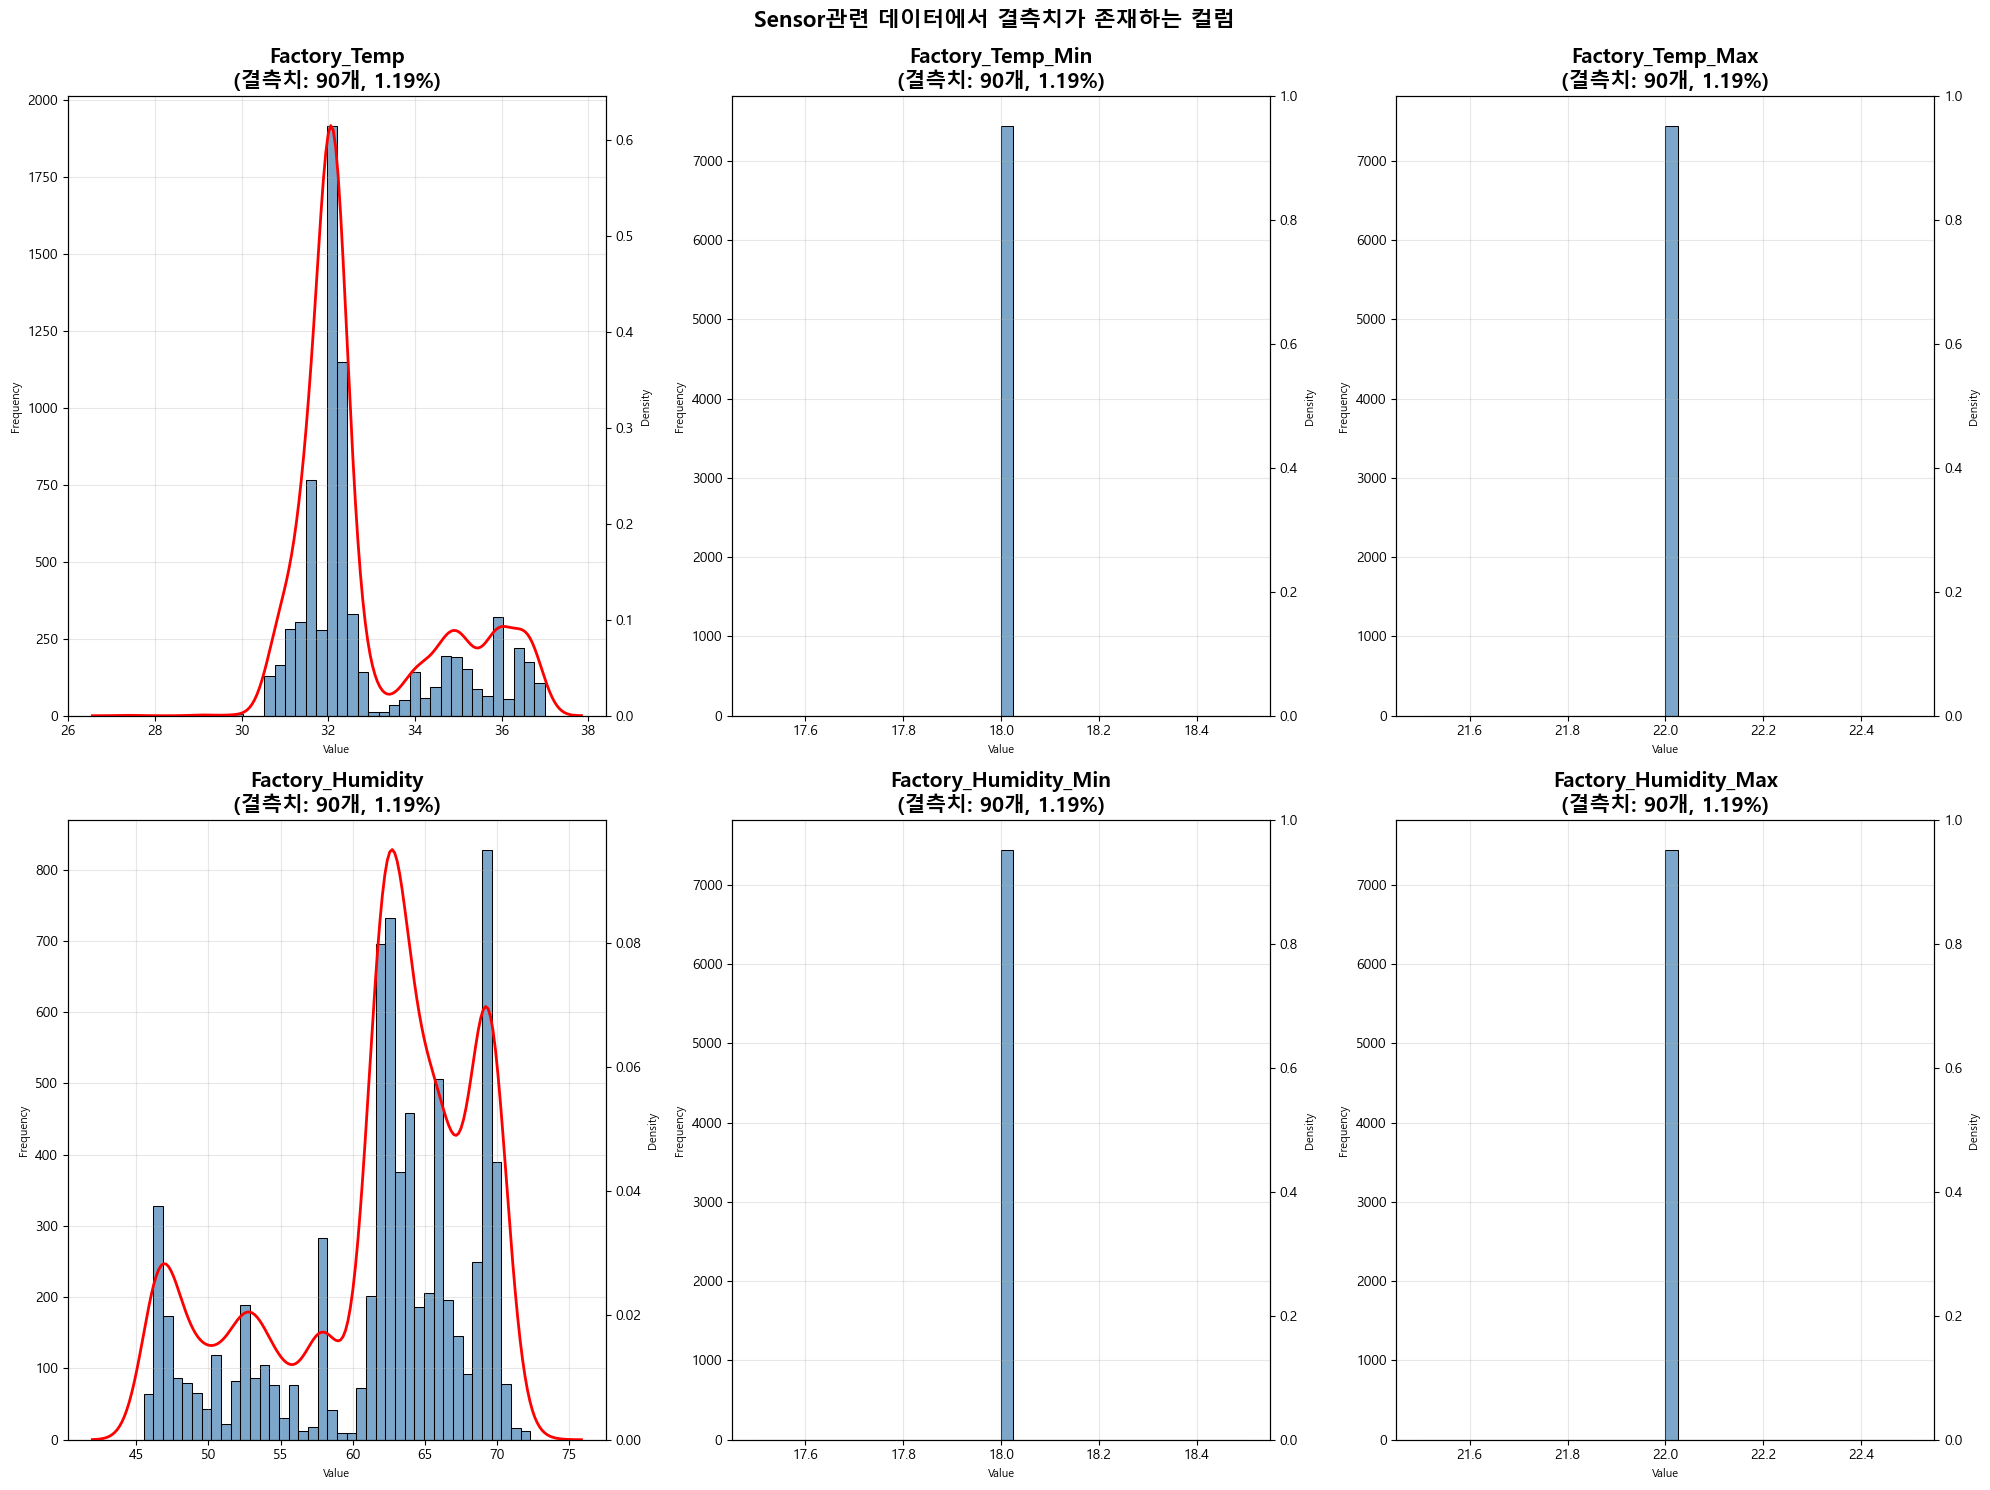


Process관련 데이터 중 결측치가 있는 컬럼이 없습니다.

Defects관련 데이터 중 결측치가 있는 컬럼이 없습니다.


In [ ]:
# 함수 실행
plot_null_columns(df_sensor, 'Sensor')
plot_null_columns(df_process, 'Process')
plot_null_columns(df_defects, 'Defects')

---
## 기초통계량 확인
- Process, Sensor 관련 데이터 확인
- Defect 관련 데이터의 고유값 확인

In [17]:
# Process, Sensor 관련 데이터 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기본 통계량
    stats_df = df_copied.describe().T
    
    # 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

In [18]:
# 함수 실행
stats_df_process = create_statistics_summary(df_process, 'Process', exclude_cols=['id', 'Product_Type'])
stats_df_sensor = create_statistics_summary(df_sensor, 'Sensor')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
Shot,7535.0,453.798938,319.451698,0.000,195.000,401.000,645.000,1296.000,1271,0.700880,-0.281888
Velocity_1,7535.0,0.148219,0.007134,0.134,0.142,0.144,0.156,0.180,33,0.638906,-0.689695
Velocity_2,7535.0,0.168801,0.004720,0.158,0.166,0.168,0.170,0.212,27,4.087670,28.913573
Velocity_3,7535.0,0.191193,0.011563,0.172,0.181,0.188,0.202,0.234,45,0.280346,-1.105678
High_Velocity,7535.0,2.319210,0.222041,0.000,2.134,2.161,2.523,2.744,319,-0.347531,5.037868
Cylinder_Pressure,7535.0,239.655607,23.305451,107.000,217.000,239.000,265.000,266.000,22,-0.017856,-1.370291
Rapid_Rise_Time,7535.0,0.009596,0.002148,0.000,0.008,0.009,0.012,0.021,18,0.332233,-0.359274
Biscuit_Thickness,7535.0,14.309622,3.286284,0.000,11.000,13.000,17.000,24.000,24,-0.012470,-0.446597
Clamping_Force,7535.0,306.433311,57.274965,238.000,255.000,258.000,372.000,388.000,42,0.272316,-1.872108
Cycle_Time,7535.0,27.735979,8.716156,20.200,20.900,22.600,35.900,218.600,61,5.316293,92.781942



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
Melting_Furnace_Temp,7535.0,680.652661,25.288666,635.30,656.70,680.30,703.10,730.00,737,0.124036,-1.284874
Air_Pressure,7535.0,6.109595,0.647906,4.60,5.70,6.20,6.60,7.10,26,-0.480152,-0.673609
Air_Pressure_Min,7535.0,3.000000,0.000000,3.00,3.00,3.00,3.00,3.00,1,0.000000,0.000000
Air_Pressure_Max,7535.0,9.000000,0.000000,9.00,9.00,9.00,9.00,9.00,1,0.000000,0.000000
Coolant_Temp,7535.0,26.830126,0.525149,25.90,26.50,26.80,27.20,28.10,23,0.486100,-0.272945
Coolant_Temp_Min,7535.0,10.000000,0.000000,10.00,10.00,10.00,10.00,10.00,1,0.000000,0.000000
Coolant_Temp_Max,7535.0,50.000000,0.000000,50.00,50.00,50.00,50.00,50.00,1,0.000000,0.000000
Coolant_Pressure,7535.0,2.701155,0.052408,2.58,2.64,2.72,2.74,2.79,22,-0.571114,-1.100549
Factory_Temp,7445.0,32.829684,1.674896,27.40,31.90,32.10,33.80,37.00,67,1.107711,-0.036236
Factory_Temp_Min,7445.0,18.000000,0.000000,18.00,18.00,18.00,18.00,18.00,1,0.000000,0.000000


In [19]:
# Defect 관련 데이터의 고유값 확인 
# 0, 1를 제외한 데이터가 섞여있다면 비율도 확인할 예정

def analyze_each_column_distribution(df, df_name):
    
    print(f"{'='*80}")
    print(f"{df_name}의 컬럼별 값 분포")
    print(f"{'='*80}")
    
    for col in df.columns:
        print(f"\n[{col}]")
        
        # 고유값 및 정렬
        unique_values = sorted(df[col].unique())
        
        # 고유값별 개수와 비율
        # .value_counts(): 각 고유값의 개수 계산 (빈도수 많은 순)
        # .sort_index(): 고유값 순서대로 재정렬 (오름차순)
        value_counts = df[col].value_counts().sort_index()
        
        # 분포 테이블 생성
        dist_list = []
        for val in unique_values:
            count = value_counts.get(val, 0)
            pct = round(count / len(df) * 100, 2)
            dist_list.append({
                '고유값': val,
                '개수': count,
                '비율(%)': pct
            })
        
        dist_df = pd.DataFrame(dist_list)
        display(dist_df)

In [20]:
# 함수 실행
analyze_each_column_distribution(df_defects, 'Defects')

Defects의 컬럼별 값 분포

[Short_Shot_1]


,고유값,개수,비율(%)
0,0,7038,93.4
1,1,482,6.4
2,2,15,0.2



[Bubble_1]


,고유값,개수,비율(%)
0,0,7463,99.04
1,1,72,0.96



[Exfoliation_1]


...

,고유값,개수,비율(%)
0,0,7535,100.0



[Buring_Mark_2]


,고유값,개수,비율(%)
0,0,7535,100.0



[Inclusions_2]


,고유값,개수,비율(%)
0,0,7534,99.99
1,1,1,0.01
